### Importing Packages

In [104]:
## Importing Packages 
import warnings
warnings.filterwarnings("ignore")

from typing import Dict
import os
import ssl
import openpyxl
import sys
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import yfinance as yf

import random
from scipy import stats
from scipy.stats import skew, kurtosis, kendalltau
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

# Importing HMM model for Markov Regime Switching
import statsmodels.api as sm 
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

### Setting Plotting Theme

In [3]:
## Setting Plotting Theme
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.grid"] = True
%matplotlib inline

sns.set_theme(
        style="darkgrid",
        context="notebook",
        font_scale=1.1,
        rc={
            "axes.facecolor": "#EAEAF2",
            "figure.facecolor": "white",
            "grid.color": "white",
            "grid.linewidth": 1.0,
            "axes.edgecolor": "#EAEAF2",
            "axes.labelweight": "bold",
            "axes.titleweight": "bold",
        },
    )

### Data

In [4]:
file_path = r'C:\Users\Admin\Documents\GitHub\Complexity-Theory-Masters-Thesis\Data'
os.chdir(file_path)

In [5]:
## Reading-in the data
df_spain_yields = pd.read_excel("Spread_Data.xlsx", sheet_name="Spain_Benchmark_Yields").copy()
df_germany_yields = pd.read_excel("Spread_Data.xlsx", sheet_name="Germany_Benchmark_Yields").copy()
df_us_indices = pd.read_excel("US_spreads_GFC.xlsx", sheet_name="GFC_Spreads").copy()

df_spain_yields["Date"] = pd.to_datetime(df_spain_yields["Date"])
df_germany_yields["Date"] = pd.to_datetime(df_germany_yields["Date"])
df_us_indices["Date"] = pd.to_datetime(df_us_indices["Date"])

df_spain_yields = df_spain_yields.set_index("Date").sort_index()
df_germany_yields = df_germany_yields.set_index("Date").sort_index()
df_us_indices = df_us_indices.set_index("Date").sort_index()

df_spain_yields = df_spain_yields.dropna()
df_germany_yields = df_germany_yields.dropna()
df_us_indices = df_us_indices.dropna()

In [6]:
df_spain_yields

,SPAIN GVT BMK BID YLD 5Y,SPAIN GVT BMK BID YLD 10Y,SPAIN GVT BMK BID YLD 30Y
Date,,,
1999-12-31,5.129,5.572,6.113
2000-01-03,5.219,5.690,6.186
2000-01-04,5.246,5.763,6.204
2000-01-05,5.238,5.744,6.205
2000-01-06,5.256,5.781,6.274
...,...,...,...
2026-03-05,2.757,3.312,4.030
2026-03-06,2.819,3.363,4.052
2026-03-09,2.819,3.355,4.052


#### Construction of the Spain–Germany Sovereign Spread

*The baseline spread series is constructed from daily 5Y, 10Y and 30Y rolling benchmark government bond yields for Spain and Germany. These benchmark yields provide liquid market reference rates for each maturity, though they do not correspond to a single fixed security over time.*

For our thesis, we define the sovereign spread as:

$$
\text{Spread}_t = y^{\text{Spain}}_t - y^{\text{Germany}}_t
$$

where:

- $y^{\text{Spain}}_t$ is the Spanish government bond yield at time $t$
- $y^{\text{Germany}}_t$ is the German government bond yield at time $t$

Thus, the spread is computed by **subtracting the German yield from the Spanish yield**.

##### Interpretation

This definition is appropriate because Germany serves as the core benchmark sovereign issuer in the euro area, while Spain is treated as the relatively riskier issuer. Therefore:

- a **higher spread** indicates greater relative stress or risk in Spanish sovereign bonds,
- a **declining spread** indicates relative stabilization,
- and a **widening spread** is naturally interpretable as deterioration in Spain relative to Germany.

For this reason, the spread should be constructed as:

- **5Y spread** = Spain 5Y yield − Germany 5Y yield
- **10Y spread** = Spain 10Y yield − Germany 10Y yield
- **30Y spread** = Spain 30Y yield − Germany 30Y yield

Although, in this notebook we will primarily focus on the **5Y spread** 

In [7]:
## Build all Spain-Germany spreads dataframe
spreads = (
    pd.DataFrame({
        "5Y":  df_spain_yields["SPAIN GVT BMK BID YLD 5Y"]  - df_germany_yields["GERMANY GVT BMK BID YLD 5Y"],
        "10Y": df_spain_yields["SPAIN GVT BMK BID YLD 10Y"] - df_germany_yields["GERMANY GVT BMK BID YLD 10Y"],
        "30Y": df_spain_yields["SPAIN GVT BMK BID YLD 30Y"] - df_germany_yields["GERMANY GVT BMK BID YLD 30Y"],
    })
    .rename(columns={"5Y": "ES-DE 5Y", "10Y": "ES-DE 10Y", "30Y": "ES-DE 30Y"})
)
es_de_spread_5y = df_spain_yields['SPAIN GVT BMK BID YLD 5Y'] - df_germany_yields['GERMANY GVT BMK BID YLD 5Y']
es_de_spread_5y_df = es_de_spread_5y.to_frame(name='es_de_5y_spread')
es_de_spread_10y = df_spain_yields['SPAIN GVT BMK BID YLD 10Y'] - df_germany_yields['GERMANY GVT BMK BID YLD 10Y']
es_de_spread_10y_df = es_de_spread_10y.to_frame(name='es_de_10y_spread')
es_de_spread_30y = df_spain_yields['SPAIN GVT BMK BID YLD 30Y'] - df_germany_yields['GERMANY GVT BMK BID YLD 30Y']
es_de_spread_30y_df = es_de_spread_30y.to_frame(name='es_de_30y_spread')

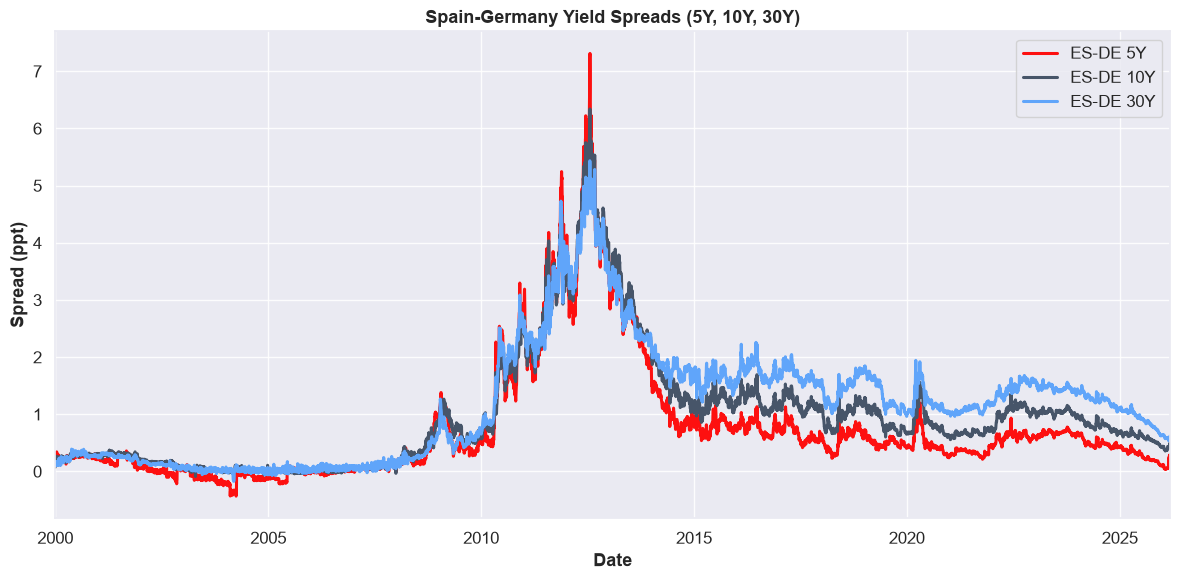

In [8]:
## Plotting all spreads
colors = ["#FD1010", "#475569", "#60A5FA"]  # 5Y, 10Y, 30Y
ax = spreads.plot(figsize=(12, 6), color=colors, linewidth=2.2, title="Spain-Germany Yield Spreads (5Y, 10Y, 30Y)")
ax.set_ylabel("Spread (ppt)")
ax.set_xlabel("Date")
ax.grid(True, which="major", color="white", alpha=0.9, linewidth=1.0)
plt.tight_layout()
plt.show()

### Fitting Two-state Markov-switching AR(1) Model

The original paper by **van den end (2019)** used a two-regime Markov-switching autoregressive model to date specific ECB-liquidity-related interest-rate transitions, while we adapted the same idea to classify Spain–Germany sovereign-spread regimes, using a two-state Markov-switching AR(1) model with regime-dependent volatility.

Following van den End’s use of Markov-switching regression to obtain a statistical indication of interest-rate regime shifts, we estimate a two-state Markov-switching autoregressive model for the Spain–Germany 5Y sovereign yield spread. While van den End applies the model to euro-area money-market and safe-asset rate margins, this thesis applies the same logic to sovereign fragmentation risk, measured by the Spanish benchmark yield spread over Germany. The model is used to obtain smoothed probabilities of calm and stress regimes. However, consistent with van den End’s caution, the Markov-switching results are interpreted as a statistical dating device rather than as standalone evidence of a critical transition.

#### Analysing Suitability of Spread Data for HMM

In [ ]:
## Analysing yield distribution of Spain-Germany 5Y benchmark yield spread
def plot_return_distribution(returns, title="Return Distribution Analysis", label="Returns"):
    
    # Ensure returns is a pandas Series and drop NaNs
    returns = pd.Series(returns).dropna()

    # Compute stats
    mean = returns.mean()
    std = returns.std()
    skew = returns.skew()
    kurt = returns.kurtosis()
    jb_stat, jb_p = stats.jarque_bera(returns)

    # Set up figure
    plt.figure(figsize=(16, 12))

    # Histogram + KDE + Normal PDF
    plt.subplot(2, 2, 1)
    sns.histplot(returns, kde=True, stat="density", bins=50, color="skyblue", label="Empirical")
    x_vals = np.linspace(returns.min(), returns.max(), 500)
    plt.plot(x_vals, stats.norm.pdf(x_vals, mean, std), color='red', linestyle='--', label='Normal')
    plt.title("Histogram + KDE vs Normal PDF")
    plt.xlabel(label)
    plt.ylabel("Density")
    plt.legend()

    # QQ Plot
    plt.subplot(2, 2, 2)
    stats.probplot(returns, dist="norm", plot=plt)
    plt.title("QQ Plot (Normality Check)")

    # Boxplot
    plt.subplot(2, 2, 3)
    sns.boxplot(x=returns, color="lightgreen")
    plt.title("Boxplot")
    plt.xlabel(label)

    # Empirical CDF
    plt.subplot(2, 2, 4)
    sorted_returns = np.sort(returns)
    ecdf = np.arange(1, len(sorted_returns) + 1) / len(sorted_returns)
    plt.plot(sorted_returns, ecdf, marker='.', linestyle='none', label="Empirical CDF")
    plt.plot(x_vals, stats.norm.cdf(x_vals, mean, std), 'r--', label="Normal CDF")
    plt.title("Empirical CDF vs Normal CDF")
    plt.xlabel(label)
    plt.ylabel("CDF")
    plt.legend()

    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # Print descriptive statistics
    print("==== Return Distribution Statistics ====")
    print(f"Mean       : {mean:.6f}")
    print(f"Std Dev    : {std:.6f}")
    print(f"Skewness   : {skew:.4f}")
    print(f"Kurtosis   : {kurt:.4f}")
    print(f"Jarque-Bera Stat: {jb_stat:.4f}")
    print(f"Jarque-Bera p-val: {jb_p:.4f} (p < 0.05 suggests non-normality)")
    
    plt.show()

In [16]:
## Selecting the exact Spain-Germany XY Spread we will analyse
chosen_spread_to_analyse = es_de_spread_5y_df['es_de_5y_spread']
chosen_label = "Spain-Germany 5Y Yield Spread"

==== Return Distribution Statistics ====
Mean       : 0.753241
Std Dev    : 1.064954
Skewness   : 2.4369
Kurtosis   : 6.3778
Jarque-Bera Stat: 18323.3700
Jarque-Bera p-val: 0.0000 (p < 0.05 suggests non-normality)


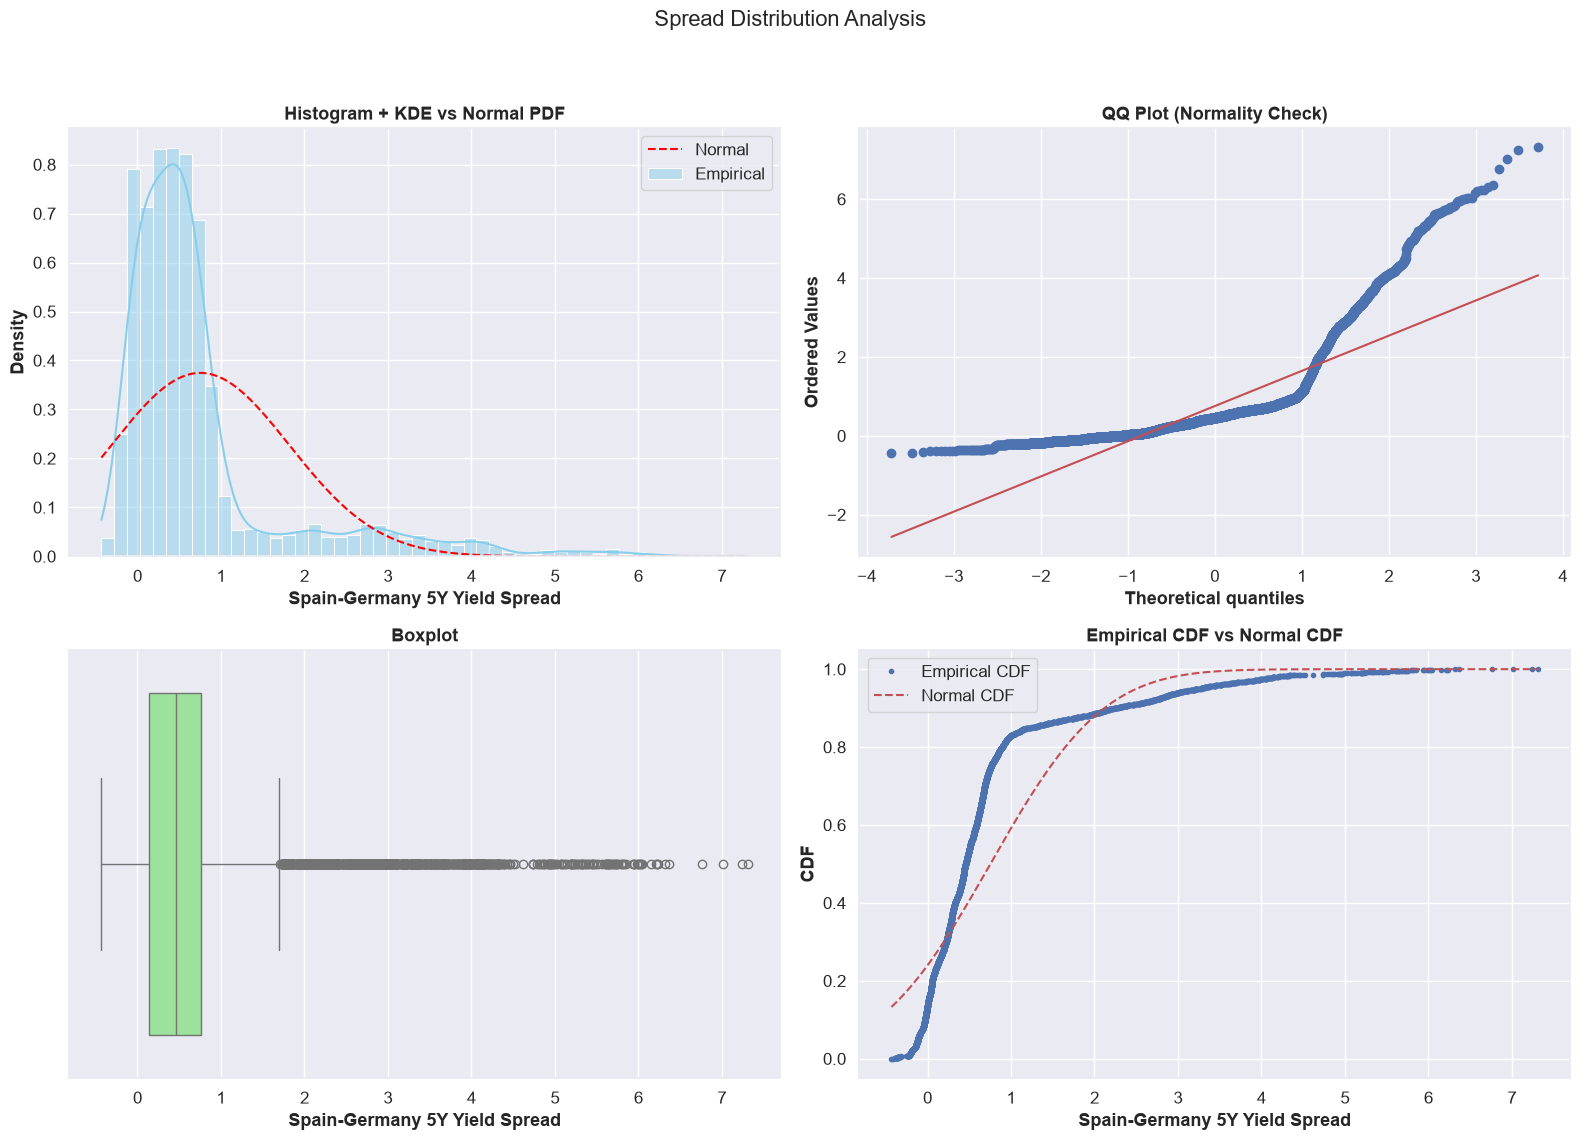

In [17]:
## Diagnostics
plot_return_distribution(returns = es_de_spread_5y_df['es_de_5y_spread'], title="Spread Distribution Analysis", label=chosen_label)

##### Interpretation of each panel
**1. Histogram + KDE vs normal PDF**

The histogram shows that most observations are concentrated in a relatively low spread range, roughly between 0 and 1. This corresponds to periods in which Spanish sovereign risk was only moderately above German sovereign risk.

However, the distribution has a long right tail, with spread values extending above 5 or 6. These observations likely correspond to episodes of sovereign stress, especially periods when Spanish yields rose strongly relative to German Bund yields.

The normal density does not fit the empirical distribution well. The empirical distribution is much more peaked around low spread values and has far more mass in the right tail than a normal distribution would imply. Therefore, a single Gaussian distribution is not a good description of the full sample.

**2. QQ plot**

The QQ plot strongly confirms non-normality. If the spread were approximately normally distributed, the blue points would lie close to the red line. Instead, the points bend away from the line, especially in the upper tail.

The right side of the QQ plot shows that high spread observations are much larger than a normal distribution would predict. This indicates positive skewness and fat right-tail behaviour. Economically, that means Spanish sovereign stress episodes are not just ordinary fluctuations around a stable mean; they are extreme and asymmetric episodes.

The left tail is much less extreme than the right tail. This makes sense economically, because the Spain–Germany spread has a natural lower bound: Spain normally does not trade far below Germany, while it can trade far above Germany during crisis periods.

**3. Boxplot**

The boxplot reinforces the same point. Most observations lie in a compact central range, but there are many large positive outliers. These are not necessarily “bad data points”; in a sovereign-spread context, they are economically meaningful observations.

They likely represent stress periods in which investors demanded a much higher yield to hold Spanish debt relative to German debt. These outliers are the kind of observations that may correspond to stress regimes, fragmentation risk, or critical transitions.

**4. Empirical CDF vs normal CDF**

The empirical CDF rises much faster than the normal CDF at low spread values, meaning that a large share of the sample is concentrated in low-spread states. Later, the empirical CDF approaches 1 more slowly in the right tail, reflecting the presence of extreme high-spread observations.

This again confirms that the distribution is not symmetric and not well approximated by a single normal distribution.

**5. Main conclusion**

**The plot suggests that the Spain–Germany 5Y spread is:**
* positively skewed,
* right-tailed,
* non-normal,
* and likely regime-dependent.

This is relevant for fitting a Markov-switching model. A single normal model would assume that all observations come from one stable distribution. THe diagnostic plot suggests the opposite: most observations belong to a low-spread regime, while a smaller number of observations belong to a high-spread stress regime.

This supports the use of a two-state Markov-switching model, because the unconditional distribution looks like it may be a mixture of at least two states: a calm/normal regime and a stress/widening-spread regime. This fits the objective of the thesis of using Markov regimes to date spread regime changes before testing early-warning indicators.

**ADF Test:**
* **Null hypothesis (H₀):** the series has a unit root → it is non-stationary
* **Alternative hypothesis (H₁):** the series is stationary

In [21]:
## ADF Test on Spain-Germany 5Y Spread
result_raw = adfuller(chosen_spread_to_analyse)
print("ADF Test on " + chosen_label + ":")
print(f"  ADF Statistic : {result_raw[0]:.4f}")
print(f"  p-value       : {result_raw[1]:.4f}")
for key, value in result_raw[4].items():
    print(f"  Critical Value ({key}) : {value:.4f}")

ADF Test on Spain-Germany 5Y Yield Spread:
  ADF Statistic : -2.2832
  p-value       : 0.1774
  Critical Value (1%) : -3.4313
  Critical Value (5%) : -2.8620
  Critical Value (10%) : -2.5670


The **full-sample ADF test** fails to reject the unit-root null, indicating strong persistence in the Spain–Germany 5-year spread. This supports the use of a regime-switching autoregressive specification rather than a simple independent Gaussian HMM, since the spread appears to exhibit both persistence and potential regime-dependent behaviour.

#### Checking ACF and PACF

In [ ]:
## Converting 5Y Spread data into dataframe
spread_to_analyse = es_de_spread_5y_df.copy()
spread_to_analyse_column_name = 'es_de_5y_spread'
new_df = pd.DataFrame(data = spread_to_analyse.values, index= spread_to_analyse.index, columns=[spread_to_analyse_column_name])

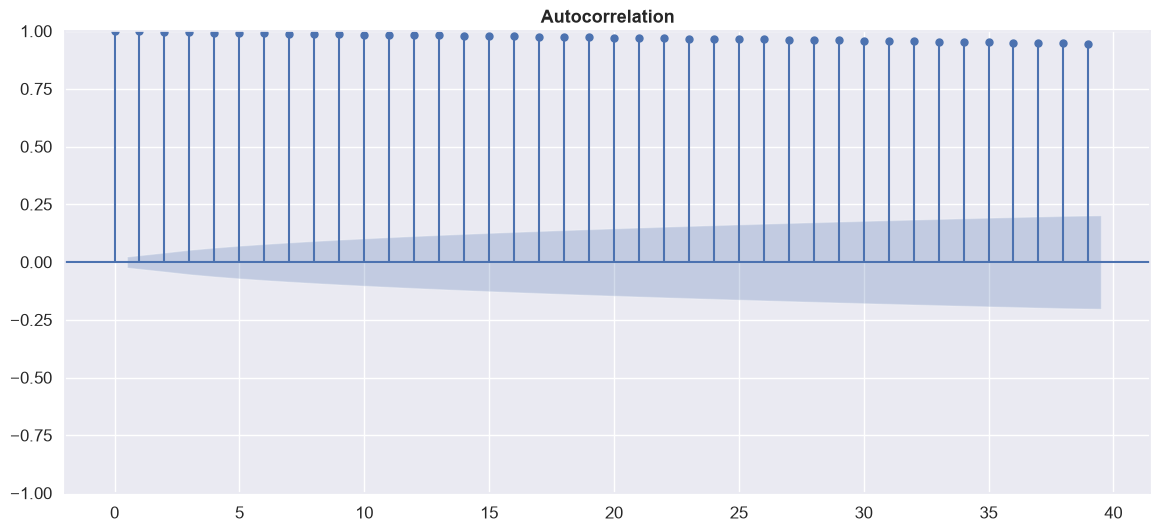

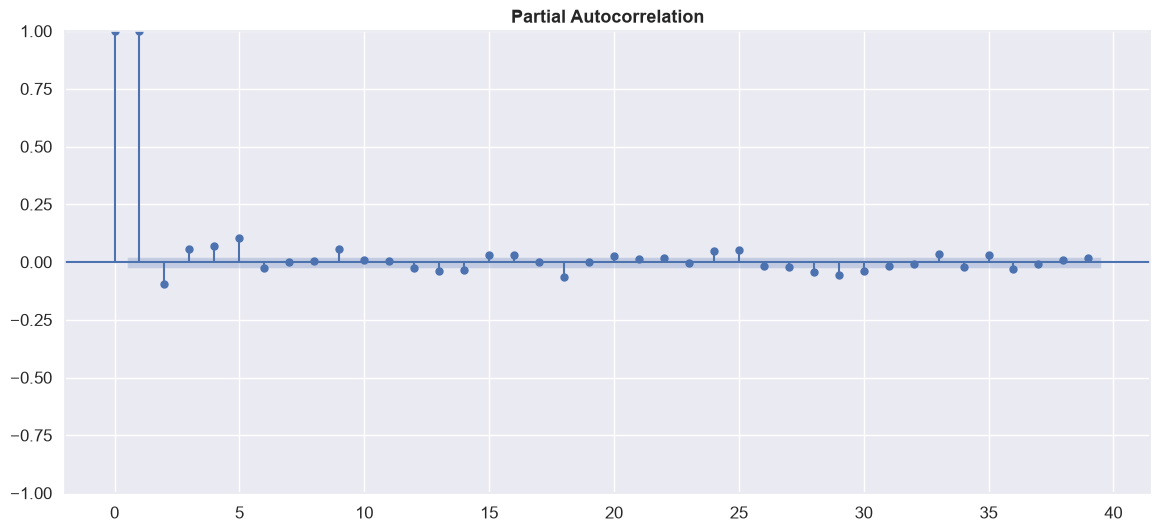

In [23]:
## Checking whether the spread value on the previous day is a good predictor for the next day (i.e., whether the spread follows an AR(1) process or is close to a random walk)
plot_acf(spread_to_analyse.values) # AutoCorrelation Function Shows correlation of the series with its own lagged values (lag 1, lag 2, etc.)
plot_pacf(spread_to_analyse.values) # ACF = Partial AutoCorrelation Function Shows correlation at each lag after removing effects of shorter lags.
plt.show()

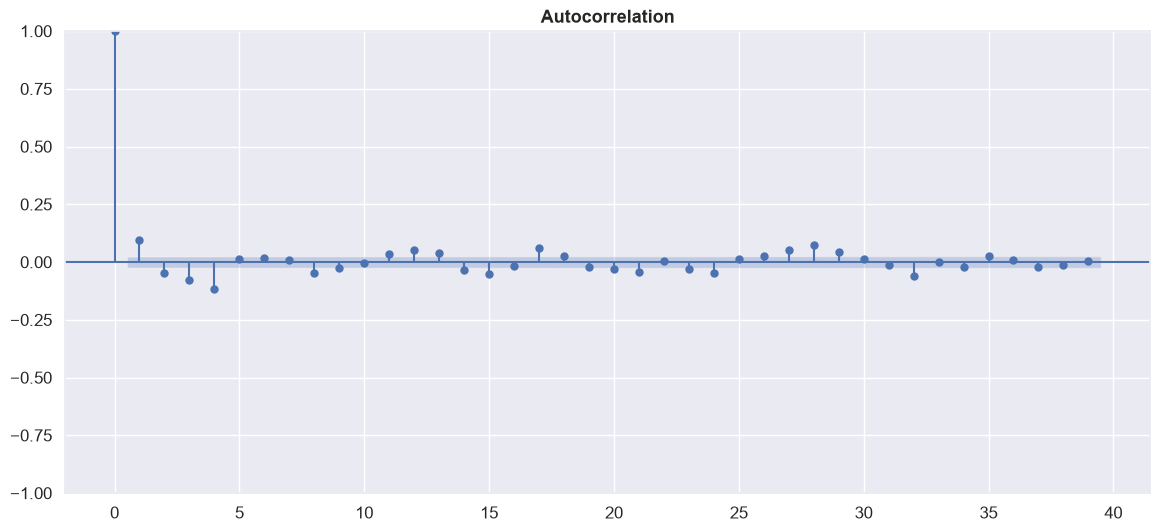

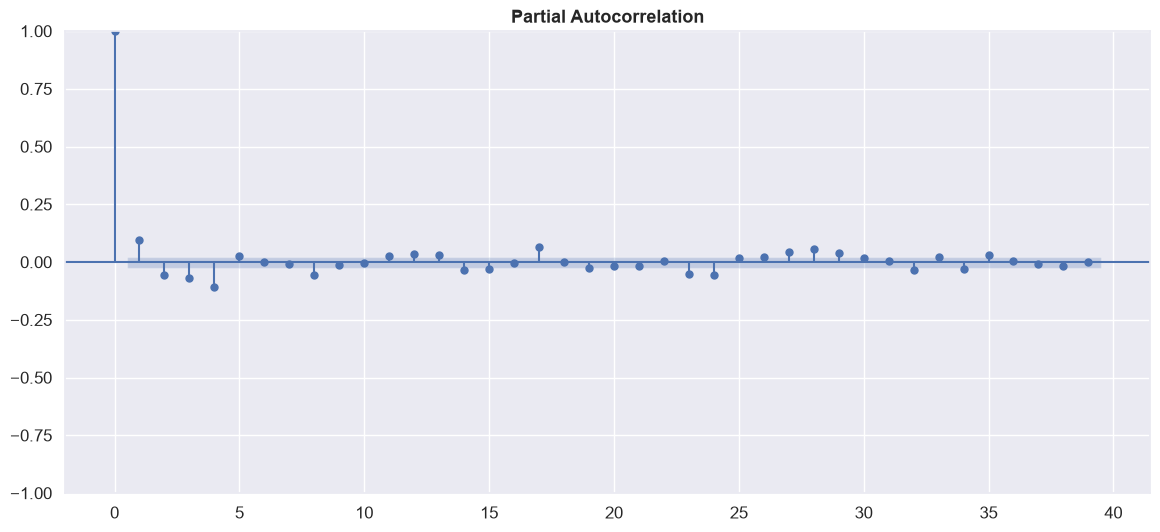

In [24]:
## Checking if the changes in sovereign spreads are serially correlated
spread_difference = spread_to_analyse[spread_to_analyse_column_name].diff().dropna()
plot_acf(spread_difference.values) # AutoCorrelation Function Shows correlation of the series with its own lagged values (lag 1, lag 2, etc.)
plot_pacf(spread_difference.values) # ACF = Partial AutoCorrelation Function Shows correlation at each lag after removing effects of shorter lags.
plt.show()

In conclusion, the **ACF/PACF** is suggesting that the dominant dependence is at lag 1. So fitting HMM AR(1) might be the most appropriate, but HMM AR(2) or AR(3) could be fitted as robustness checks.

##### Why ACF/PACF are useful here

**1. Check for Temporal Structure (Memory)**
ACF of the spread level tells you:
“How persistent is the spread?”
→ If autocorrelations stay high for many lags, it suggests spread levels are serially correlated, i.e., they don’t revert quickly.

This supports using time-dependent models like HMMs, which assume that the hidden state evolves over time and that observations depend on state.

**2. Differentiate Between Stationary and Non-stationary Behavior**
If the spread level ACF decays slowly, it might be non-stationary (e.g., has a trend or persistent structure).

Taking .diff() (first difference) helps check if the result is more stationary, which is better suited for modeling in many cases.

**3. Model Diagnostics**
If drawdown.diff() shows no significant autocorrelation, it might mean: We have removed the serial dependence.

Or the spread level is effectively white noise in differences.

That can guide whether a single-layer HMM is enough, or if we would need something more complex (e.g., regime-switching AR models).

##### Choosing between a Gaussian HMM and a Markov-switching AR model

The ACF and PACF are helpful for deciding whether a simple Gaussian HMM is sufficient.

A plain Gaussian HMM classifies observations into different hidden regimes, such as a low-spread regime and a high-spread regime. However, it does not explicitly model the fact that today’s spread may depend strongly on yesterday’s spread.

A Gaussian HMM assumes:

$$
s_t \mid q_t = k \sim \mathcal{N}(\mu_k, \sigma_k^2)
$$

where $q_t$ is the hidden regime at time $t$.

By contrast, a Markov-switching **autoregressive model** allows the spread to follow an autoregressive process inside each regime:

$$
s_t = c(q_t) + \phi s_{t-1} + \varepsilon_t
$$

with:

$$
\varepsilon_t \mid q_t = k \sim \mathcal{N}(0, \sigma_k^2)
$$

This means that the model separates two sources of persistence:

1. ordinary persistence in the spread itself;
2. genuine shifts in the regime governing the spread process.

This distinction is important for the Spain–Germany 5Y spread because sovereign spreads can potentially be highly persistent. A Markov-switching AR model is therefore more appropriate when the spread shows strong autocorrelation, because it allows the spread to remain persistent within regimes while still permitting shifts in the intercept and/or volatility across regimes.

### Analysing Regime Switches

Currently Selected Date Range for Analysis: from 2009-01-01 to 2013-07-31


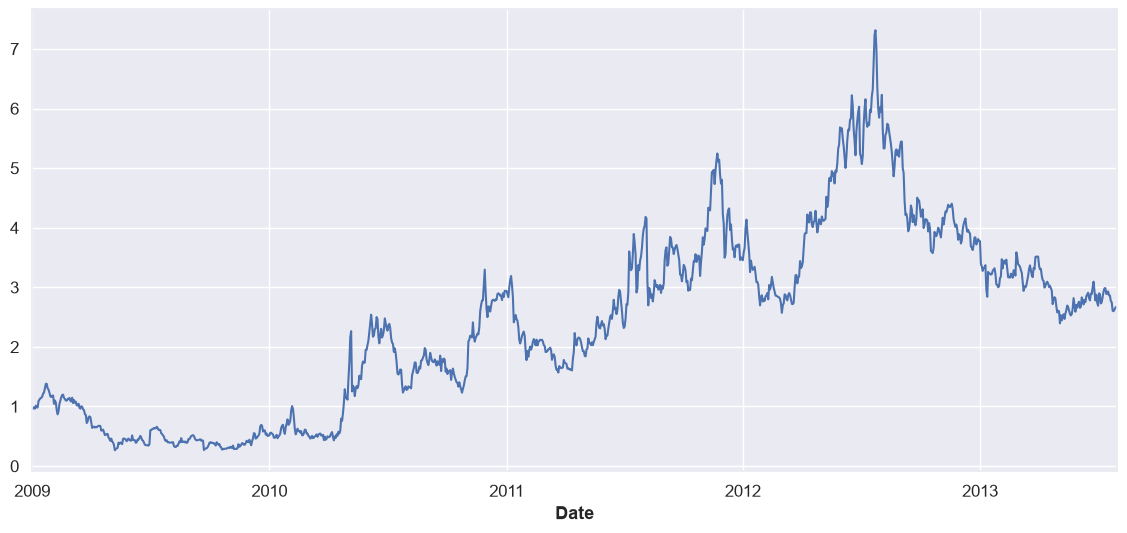

In [29]:
################################################
###### Choosing the interval to analyse  #######
s_date = "2009-01-01"
e_date = "2013-07-31"
################################################
spread_to_analyse = es_de_spread_5y_df.loc[s_date:e_date].copy()
spread_to_analyse_column_name = 'es_de_5y_spread'
new_df = pd.DataFrame(data = spread_to_analyse.values, index= spread_to_analyse.index, columns=[spread_to_analyse_column_name])
print(f'Currently Selected Date Range for Analysis: from {s_date} to {e_date}')
new_df['es_de_5y_spread'].plot()
plt.show()

In [30]:
new_df.head()

,es_de_5y_spread
Date,
2009-01-01,0.953
2009-01-02,0.970
2009-01-05,0.985
2009-01-06,0.963
2009-01-07,1.013
...,...
2013-07-25,2.599
2013-07-26,2.627
2013-07-29,2.659


#### Fitting Autoregressive Hidden Markov Model - AR(1)

In [ ]:
## Function for fitting a Markov-switching AR(p) model

def fit_markov_switching_ar(
    new_df, # the dataframe containing the spread and date columns
    y_col, # the name of the column in new_df that contains the spread values to model
    reorder_col, # the name of the column in new_df that contains the spread values used for reordering regimes (can be the same as y_col)
    k_regimes=2, # number of regimes
    order=1, 
    switching_ar=False,
    switching_variance=True, # whether to allow variance to switch across regimes, we usually want this for financial data but not for other applications
    standardise=False, # Optional feature for standardisation, we don't use it currently for spreads but it can be useful for other applications
    search_reps=20, # number of random initialisations for the EM algorithm to avoid local minima
    em_iter=20, # number of EM iterations per random initialisation
    maxiter=1000, # maximum number of iterations for the final model fit after selecting the best random initialisation
    fill_initial_missing=True # whether to fill the initial missing regime label (due to AR(1) lag) with the first available regime, this can help avoid issues in plotting functions that expect no missing values in the regime column
):
    """
    Fits a Markov-switching AR(p) model and stores the outputs using the following
    column names:
    - HMM_Regime
    - HMM_Regime_Reordered
    - HMM_Prob_State_0, HMM_Prob_State_1, ...

    Important Parameter
    ----------
    order : int
        Autoregressive order p. For example:
        order=1 gives MS-AR(1),
        order=2 gives MS-AR(2),
        order=3 gives MS-AR(3).
    """

    df = new_df.copy()

    # ------------------------------------------------------------
    # 1. Prepare dependent variable
    # ------------------------------------------------------------
    y = df[y_col].dropna().copy()

    if standardise:
        y_fit = (y - y.mean()) / y.std()
    else:
        y_fit = y.copy()

    # ------------------------------------------------------------
    # 2. Fit Markov-switching AR(p)
    # ------------------------------------------------------------
    model = sm.tsa.MarkovAutoregression(
        y_fit,
        k_regimes=k_regimes,
        order=order,
        trend="c",
        switching_ar=switching_ar,
        switching_variance=switching_variance
    )

    res = model.fit(
        search_reps=search_reps,
        em_iter=em_iter,
        maxiter=maxiter,
        disp=False
    )

    # ------------------------------------------------------------
    # 3. Extract smoothed regime probabilities
    # ------------------------------------------------------------
    smoothed_probs = res.smoothed_marginal_probabilities

    if not isinstance(smoothed_probs, pd.DataFrame):
        smoothed_probs = pd.DataFrame(
            smoothed_probs,
            index=y_fit.index[-len(smoothed_probs):],
            columns=range(k_regimes)
        )

    smoothed_probs.columns = [int(c) for c in smoothed_probs.columns]

    # ------------------------------------------------------------
    # 4. Convert probabilities into hard regime labels
    # ------------------------------------------------------------
    regimes = smoothed_probs.idxmax(axis=1).astype(int)

    df["HMM_Regime"] = np.nan
    df.loc[regimes.index, "HMM_Regime"] = regimes

    # For AR(p), statsmodels may lose the first p observations.
    # This fills the leading missing regime labels for plotting compatibility.
    if fill_initial_missing:
        df["HMM_Regime"] = df["HMM_Regime"].bfill()

    df["HMM_Regime"] = df["HMM_Regime"].astype("Int64")

    # ------------------------------------------------------------
    # 5. Store smoothed probabilities using HMM-style names
    # ------------------------------------------------------------
    for state in smoothed_probs.columns:
        prob_col = f"HMM_Prob_State_{state}"
        df[prob_col] = np.nan
        df.loc[smoothed_probs.index, prob_col] = smoothed_probs[state]

        if fill_initial_missing:
            df[prob_col] = df[prob_col].bfill()

    # ------------------------------------------------------------
    # 6. Reorder regimes using the same logic as your old HMM code
    # ------------------------------------------------------------
    mean_spreads = (
        df
        .dropna(subset=["HMM_Regime", reorder_col])
        .groupby("HMM_Regime")[reorder_col]
        .mean()
    )

    sorted_regimes = mean_spreads.sort_values(ascending=False).index

    regime_map = {
        old: new
        for new, old in enumerate(sorted_regimes, start=1)
    }

    df["HMM_Regime_Reordered"] = (
        df["HMM_Regime"]
        .map(regime_map)
        .astype("Int64")
    )

    return df, res, smoothed_probs, regime_map

In [ ]:
## Fitting HMM AR(1) Model to the Spain-Germany 5Y Spread

new_df, res, smoothed_probs, regime_map = fit_markov_switching_ar(
    new_df=new_df,
    y_col=spread_to_analyse_column_name,
    reorder_col=spread_to_analyse_column_name,
    k_regimes=2,
    order=1,
    switching_ar=True, # this should be true in the case of our current research, since complexity theory suggests that ρ rises before a regime shift, which is the core of the Critical Slowing Down and Autocorrelation claims. If we keep the AR coefficient fixed across calm and stress regimes, we are imposing exactly the null that our Critical Slowing Down/Autocorrelation analysis is built to reject. Otherwise, the two parts of our thesis would rely on different assumptions about persistence, which should be avoided.
    switching_variance=True,
    standardise=True,
    search_reps=0,
    em_iter=0,
    maxiter=1000,
    fill_initial_missing=True
)

In [40]:
## Checking HMM Setup

# 1) Verify sign + regime characteristics
spread_col = spread_to_analyse_column_name
print(new_df[spread_col].describe())
print(new_df.groupby("HMM_Regime")[spread_col].agg(["mean","std","min","max","count"]))

# 2) Verify mapping used in plots
print(regime_map)  # raw -> reordered

# 3) Plot probability of the stress raw state (reordered==1)
stress_raw = [old for old, new in regime_map.items() if new == 1][0]
new_df["P_stress_smoothed"] = new_df[f"HMM_Prob_State_{stress_raw}"]


count    1195.000000
mean        2.403261
std         1.521780
min         0.265000
25%         1.005000
50%         2.465000
75%         3.394500
max         7.313000
Name: es_de_5y_spread, dtype: float64
                mean       std    min    max  count
HMM_Regime                                         
0           3.391076  1.230700  0.601  7.313    602
1           1.400454  1.064666  0.265  4.403    593
{np.int64(0): 1, np.int64(1): 2}


* So just to clarify, HMM Regime 0 is mapped to HMM Regime 1 and HMM Regime 1 is mapped to HMM regime 2 for easier overall interpretation and plotting
* In our configuration, Regime 1 is the **stress regime** and Regime 2 is the **normal/calm regime**
* We can see that Regime 1 has **higher** mean and volatility (mean: 3.39, std: 1.23) than Regime 2 (mean 1.40, std 1.06), so Regime 1 is the high-spread/high-volatility state.
* And also to keep in mind: we assume higher es_de_5y_spread means **more stress**

In [100]:
## Extracting AR Parameters and Labeling HMM Regimes

params = pd.Series(res.params, index=res.model.param_names)
params
ar_params = params[params.index.str.contains("ar", case=False)]
ar_params
stress_regime = (
    new_df
    .dropna(subset=["HMM_Regime", spread_to_analyse_column_name])
    .groupby("HMM_Regime")[spread_to_analyse_column_name]
    .mean()
    .idxmax()
)

calm_regime = 1 - stress_regime

print("Stress regime:", stress_regime)
print("Calm regime:", calm_regime)

print(ar_params)

Stress regime: 0
Calm regime: 1
ar.L1[0]    1.000000
ar.L1[1]    0.999998
dtype: float64


In this Markov AR(1), ρ is the AR coefficient, i.e. the ar.L1 row.

So here we have the regime-specific ρ values that the model estimates:
* Regime 0: ρ = 1.000000
* Regime 1: ρ = 0.999998

Because we set switching_ar=True, there isn’t one single ρ; there is one per regime.

* Therefore, if stress ρ would come out higher than calm ρ, we would have direct cross-validation of the Autocorrelation/Critical Slowing Down findings inside the Markov-switching framework. But we can see that this is not the case unfortunately, the model estimates that both the stress and the calm regimes have the same persistence.

In [43]:
## Transition Probabilities estimated by HMM

res.regime_transition

array([[[0.94121521],
        [0.05694433]],

       [[0.05878479],
        [0.94305567]]])

If both transition probabilities are close to 1, so the model is telling us that regimes don't flip easily, which is ideal. For reference, Van den End's Annex 1 reports two estimation tables for his money-market and safe-asset models, with P_11 and P_22 ranging from 0.94 to 0.99. Since our estimates land in a similar range, it seems like the model already has persistence built in. If they would be noticeably lower (e.g., below 0.85), this would suggest that the regime specification may require further checking.

In [44]:
## Taking a look at the model summary to check the estimated parameters and their significance
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                         Markov Switching Model Results                         
================================================================================
Dep. Variable:          es_de_5y_spread   No. Observations:                 1194
Model:             MarkovAutoregression   Log Likelihood                1474.671
Date:                   K, 16 jún. 2026   AIC                          -2933.342
Time:                          17:29:10   BIC                          -2892.661
Sample:                      01-01-2009   HQIC                         -2918.014
                           - 07-31-2013                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8031        nan        nan        nan         nan         nan
sigma2         0.0146      0.001     13.040      0.000       0.012       0.017
ar.L1          1.0000      0.001    945.643      0.000       0.998       1.002
                             Regime 1 parameters                              
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8541        nan        nan        nan         nan         nan
sigma2         0.0010      0.000      8.611      0.000       0.001       0.001
ar.L1          1.0000      0.003    388.825      0.000       0.995       1.005
                         Regime transition parameters                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
p[0->0]        0.9412      0.017     56.597      0.000       0.909       0.974
p[1->0]        0.0569      0.014      4.186      0.000       0.030       0.084
==============================================================================

Warnings:
[1] Covariance matrix calculated using numerical (complex-step) differentiation.
"""

In [99]:
## Residual Diagnostics: Autocorrelation and ARCH Effects
residuals = res.resid

# Ljung-Box checks whether the residuals still have autocorrelation
lb = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print(lb)

# ARCH-LM checks whether the residual variance is time-varying, i.e. volatility clustering.
arch_stat, arch_pval, _, _ = het_arch(residuals, nlags=10)
print(f"ARCH-LM p-value: {arch_pval:.4f}")

       lb_stat     lb_pvalue
10   74.201544  6.803292e-12
20  106.326489  9.138765e-14
ARCH-LM p-value: 0.0000


**Ljung-Box** tests whether the residuals still have autocorrelation that the AR(1) didn't capture. If the p-value is below 0.05 at lag 10 or 20, we could try switching to AR(2) by changing `order=1` to `order=2` in our `MarkovAutoregression`; our earlier PACF plot already hinted that AR(2) might be worth trying as well.

**ARCH-LM** tests whether the residuals show heteroskedasticity beyond what the regime-specific variances absorbed.

**Based on the Diagnostics, we can see that:**
* Residuals still have serial dependence (model likely misses dynamics) -> since both p-values are very close to 0; so we strongly reject: no autocorrelation
* ARCH-LM p-value = 0.1594 (> 0.05), so we do not reject no-ARCH.
No strong evidence of remaining ARCH-type conditional heteroskedasticity.

In [58]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1195 entries, 2009-01-01 to 2013-07-31
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   es_de_5y_spread       1195 non-null   float64
 1   HMM_Regime            1195 non-null   Int64  
 2   HMM_Prob_State_0      1195 non-null   float64
 3   HMM_Prob_State_1      1195 non-null   float64
 4   HMM_Regime_Reordered  1195 non-null   Int64  
 5   P_stress_smoothed     1195 non-null   float64
dtypes: Int64(2), float64(4)
memory usage: 100.0 KB


In [101]:
## We can see that the markov model has been fitted successfully and the outputs are stored in new_df next to the spread data
new_df.head()

,es_de_5y_spread,HMM_Regime,HMM_Prob_State_0,HMM_Prob_State_1,HMM_Regime_Reordered,P_stress_smoothed,spain_5y_yield,germany_5y_yield
Date,,,,,,,,
2009-01-01,0.953,1,0.006507,0.993493,2,0.006507,3.304,2.351
2009-01-02,0.970,1,0.006507,0.993493,2,0.006507,3.268,2.298
2009-01-05,0.985,1,0.004134,0.995866,2,0.004134,3.303,2.318
2009-01-06,0.963,1,0.001141,0.998859,2,0.001141,3.394,2.431
2009-01-07,1.013,1,0.002431,0.997569,2,0.002431,3.403,2.390


In [76]:
## Setting up the subset of the Spain-Germany 5Y for HMM overlay and plotting
s_date = "2009-01-01"
e_date = pd.to_datetime("2013-07-31")
df_sov_stress_5y = es_de_spread_5y_df.loc[s_date:e_date].copy()
df_sov_stress_10y = es_de_spread_10y_df.loc[s_date:e_date].copy()
df_sov_stress_30y = es_de_spread_30y_df.loc[s_date:e_date].copy()

# Adding Spanish and German yields to the dataframe (new_df) for the final plotting
new_df['spain_5y_yield'] = df_spain_yields['SPAIN GVT BMK BID YLD 5Y'].reindex(new_df.index)
new_df['germany_5y_yield'] = df_germany_yields['GERMANY GVT BMK BID YLD 5Y'].reindex(new_df.index)

In [77]:
## Setting up the crisis date, label and zoomed data for plotting
crisis_date = pd.to_datetime("2012-06-27")
crisis_date_label = "Spanish Banking Assistance"
spread_col = spread_to_analyse_column_name
spread_values = new_df[spread_col].values.reshape(-1, 1)

spain_y_col = 'spain_5y_yield'
germany_y_col = 'germany_5y_yield'

# === Zoomed price scatter ===
########################################################
looking_back_date = (crisis_date - pd.Timedelta(days=183)).strftime('%Y-%m-%d')
ending_date = str(e_date.strftime('%Y-%m-%d')) #"2009-07-31" #str(crisis_date.strftime('%Y-%m-%d')) #= e_date
zoom_df = new_df.loc[(new_df.index >= looking_back_date) & (new_df.index <= ending_date)]
########################################################

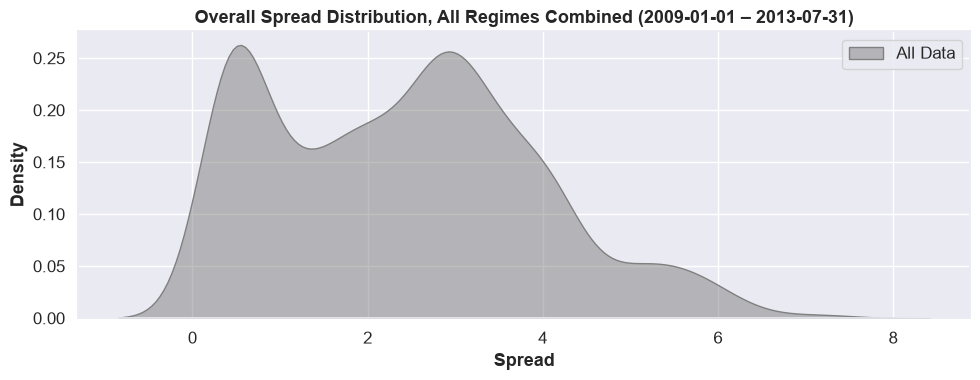

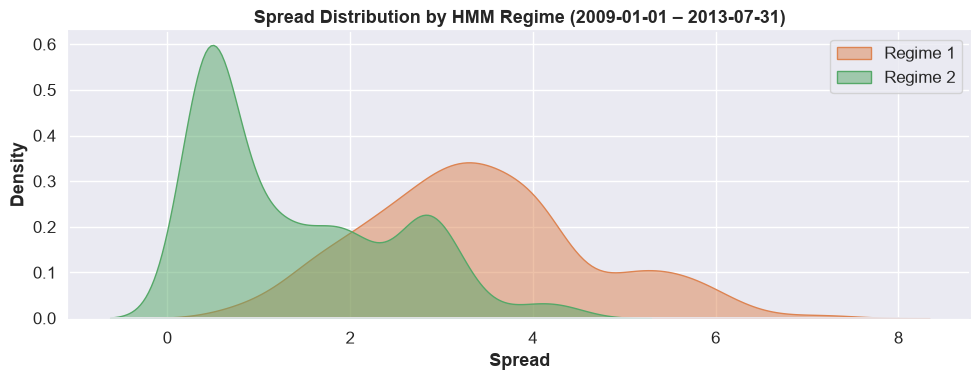

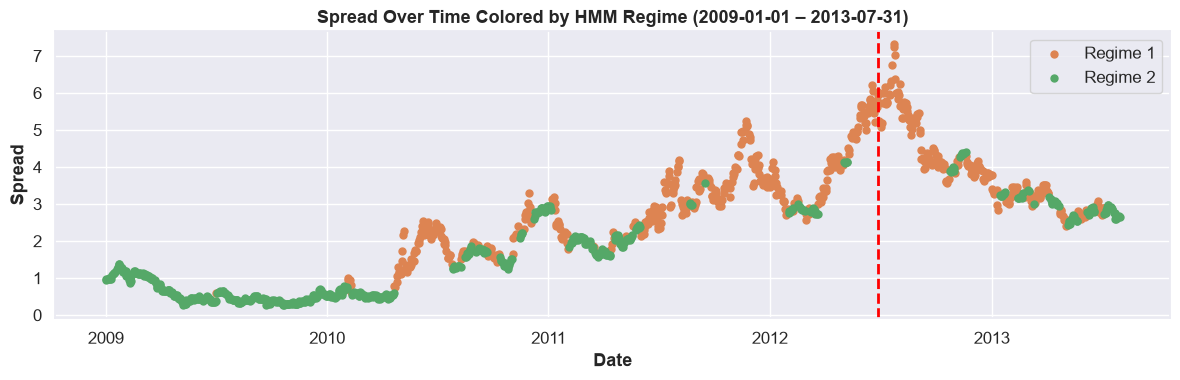

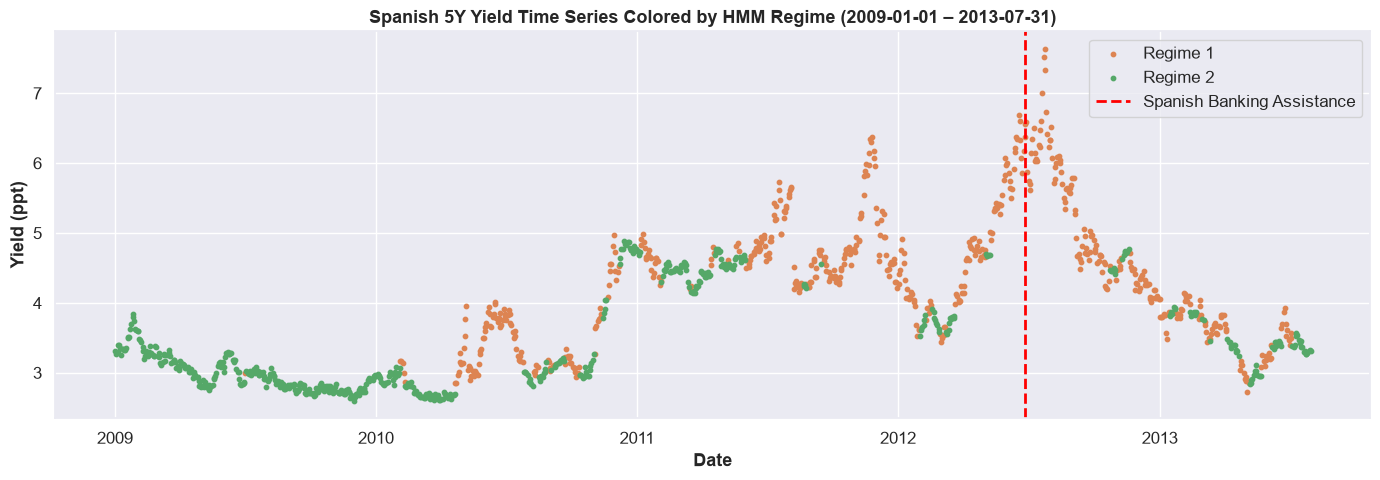

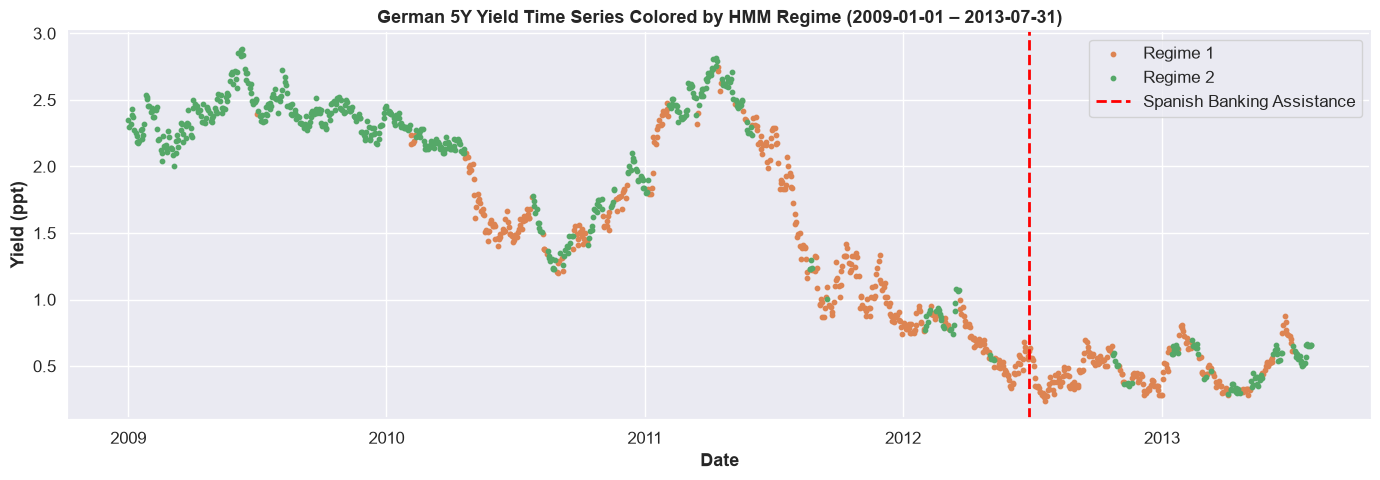

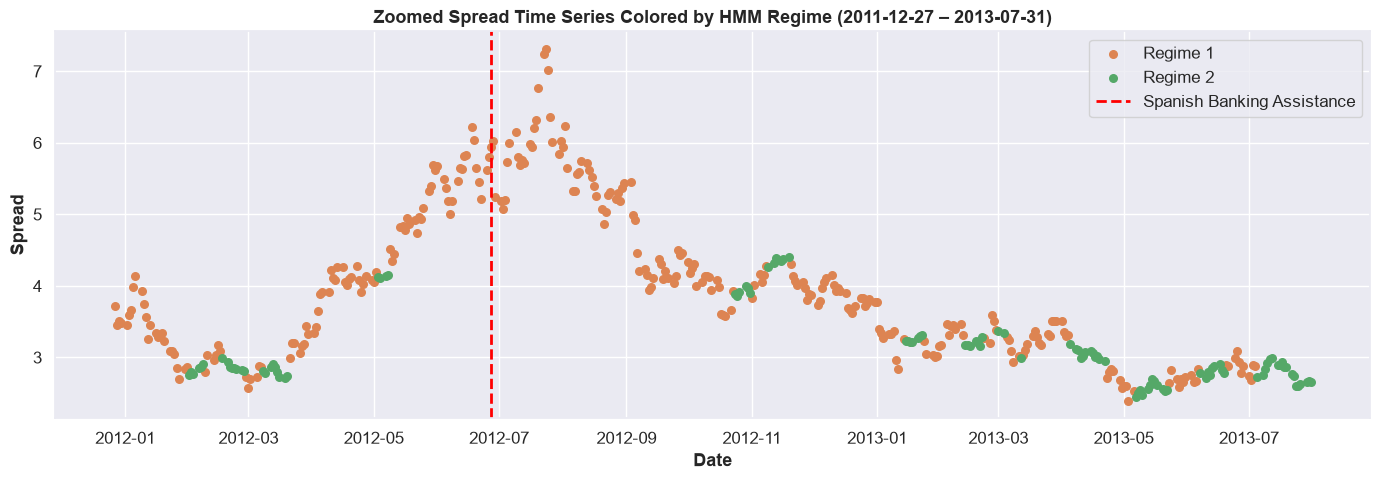

In [78]:
## Plotting Spain-Germany 5Y Spread with HMM Regimes and Spanish Banking Assistance Crisis Marker

# === KDE: All data === # X has to be checked but it should match spread_values
plt.figure(figsize=(10, 4))
sns.kdeplot(spread_values[:, 0], label="All Data", fill=True, color="gray", alpha=0.5)
plt.title(f"Overall Spread Distribution, All Regimes Combined ({s_date} – {e_date.strftime('%Y-%m-%d')})")
plt.xlabel("Spread")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === KDE: By regime ===
plt.figure(figsize=(10, 4))
for regime in sorted(new_df['HMM_Regime_Reordered'].unique()):
    sns.kdeplot(
        new_df.loc[new_df['HMM_Regime_Reordered'] == regime, spread_col],
        label=f"Regime {regime}",
        fill=True,
        alpha=0.5,
        color=f"C{regime}"
    )
plt.title(f"Spread Distribution by HMM Regime ({s_date} – {e_date.strftime('%Y-%m-%d')})")
plt.xlabel("Spread")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Spread over time colored by regime ===
plt.figure(figsize=(12, 4))
for regime in sorted(new_df['HMM_Regime_Reordered'].unique()):
    idx = new_df[new_df['HMM_Regime_Reordered'] == regime].index
    plt.scatter(idx, new_df.loc[idx, spread_col], color=f"C{regime}", s=25, label=f"Regime {regime}")
plt.legend()
plt.title(f"Spread Over Time Colored by HMM Regime ({s_date} – {e_date.strftime('%Y-%m-%d')})")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.axvline(x=crisis_date, color="red", linestyle="--", linewidth=2, label=crisis_date_label) # Adding crisis marker
plt.grid(True)
plt.tight_layout()
plt.show()

# === Price scatter plot by regime, Spanish Yields===
plt.figure(figsize=(14, 5))
for regime in sorted(new_df['HMM_Regime_Reordered'].unique()):
    regime_df = new_df[new_df['HMM_Regime_Reordered'] == regime]
    plt.scatter(regime_df.index, regime_df[spain_y_col], s=10, label=f"Regime {regime}", color=f"C{regime}")
plt.title(f"Spanish 5Y Yield Time Series Colored by HMM Regime ({s_date} – {e_date.strftime('%Y-%m-%d')})")
plt.xlabel("Date")
plt.ylabel("Yield (ppt)")
plt.axvline(x=crisis_date, color="red", linestyle="--", linewidth=2, label=crisis_date_label) # Adding crisis marker
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Price scatter plot by regime, German Yields===
plt.figure(figsize=(14, 5))
for regime in sorted(new_df['HMM_Regime_Reordered'].unique()):
    regime_df = new_df[new_df['HMM_Regime_Reordered'] == regime]
    plt.scatter(regime_df.index, regime_df[germany_y_col], s=10, label=f"Regime {regime}", color=f"C{regime}")
plt.title(f"German 5Y Yield Time Series Colored by HMM Regime ({s_date} – {e_date.strftime('%Y-%m-%d')})")
plt.xlabel("Date")
plt.ylabel("Yield (ppt)")
plt.axvline(x=crisis_date, color="red", linestyle="--", linewidth=2, label=crisis_date_label) # Adding crisis marker
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Zoomed price scatter ===
plt.figure(figsize=(14, 5))
for regime in sorted(zoom_df['HMM_Regime_Reordered'].unique()):
    regime_df = zoom_df[zoom_df['HMM_Regime_Reordered'] == regime]
    plt.scatter(regime_df.index, regime_df[spread_col], s=30, label=f"Regime {regime}", color=f"C{regime}")
plt.title(f"Zoomed Spread Time Series Colored by HMM Regime ({looking_back_date} – {ending_date})")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.axvline(x=crisis_date, color="red", linestyle="--", linewidth=2, label=crisis_date_label) # Adding crisis marker
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The HMM AR(1) separates the sample into a low-spread regime and a high-stress regime: Regime 1 dominates the elevated spread observations, especially around the 2012 Spanish banking assistance period, while Regime 2 mostly captures calmer, lower-spread periods. The timing looks economically sensible, since the model classifies the sharp widening and peak in Spanish yields/spreads around mid-2012 as the crisis regime, then gradually shifts back toward calmer states as spreads decline through 2013.

In [102]:
## Taking a closer look at the exact regime switches the HMM estimated

# assumes df has datetime index and HMM_Regime already filled
reg = new_df["HMM_Regime"].dropna().astype("Int64")

# optional: ensure chronological order
reg = reg.sort_index()

# True on days where regime differs from previous day
change_mask = reg.ne(reg.shift(1))

# all transition dates (excluding first row)
transition_dates = reg.index[change_mask.fillna(False)][1:]

# transition table: from -> to
transitions = pd.DataFrame({
    "date": transition_dates,
    "from_regime": reg.shift(1).loc[transition_dates].astype("Int64").values,
    "to_regime": reg.loc[transition_dates].astype("Int64").values
})

#print(f"Total transitions: {len(transitions)}")
print(f'Last Transition Date: {transitions["date"].max()}')
print(f'Currently Selected Crisis Date: {crisis_date}')
transitions.head()

Last Transition Date: 2013-07-05 00:00:00
Currently Selected Crisis Date: 2012-06-27 00:00:00


,date,from_regime,to_regime
0,2009-07-03,0,1
1,2010-02-04,1,0
2,2010-02-11,0,1
3,2010-04-22,1,0
4,2010-07-27,0,1


#### Sovereign Debt Crisis Events and the Spain-Germany 5Y Spread

In [95]:
## Function for Annotating Important Events
def annotate_events(ax, returns, events, position='top'):
    """
    Annotates major historical events on a matplotlib axis.
    
    Parameters:
        ax (matplotlib.axes.Axes): The axis to annotate on.
        returns (pd.Series): The time-indexed return series used to set x-axis limits.
        events: the events with their corresponding colour codes, that we want to plot
        position: either 'top' or 'bottom', for the annotated text
    
    | Event Type             | Color       |
    | ---------------------- | ----------- |
    | Institutional adoption | `darkgreen` |
    | Regulatory / ETF       | `blue`      |
    | Crashes / hacks        | `red`       |
    | Market milestones      | `orange`    |
    | Halvings               | `purple`    |
    """
    
    for date, label, color in events:
            date = pd.to_datetime(date)
            if returns.index.min() <= date <= returns.index.max():
                ax.axvline(date, color=color, linestyle='--', linewidth=1, alpha=0.7)
    
                # Choose Y position and vertical alignment
                if position == 'top':
                    y = ax.get_ylim()[1]
                    va = 'top'
                elif position == 'bottom':
                    y = ax.get_ylim()[0]
                    va = 'bottom'
                else:
                    y = ax.get_ylim()[1]
                    va = 'top'  # default fallback
    
                ax.text(
                    date,
                    y,
                    label,
                    rotation=90,
                    va=va,
                    ha='right',
                    fontsize=10,
                    color=color
                )

In [96]:
# --- Sovereign Debt Crisis Significant Dates ---
sov_event_legend = [
    Patch(color='red', label='Fiscal Stress / Disclosure'),
    Patch(color='blue', label='ECB Market Intervention'),
    Patch(color='darkgreen', label='ECB Liquidity Operations (LTRO)'),
    Patch(color='orange', label='Program / Policy Milestone'),
    Patch(color='purple', label='Acute Crisis Window Cutoff'),
]

sov_events = [
    ("2009-10-16", "Greek Fiscal Disclosure", "red"),
    ("2009-11-05", "Revised Greek Deficit Announcement", "red"),

    ("2010-05-10", "Securities Markets Programme (SMP) Launched", "blue"),
    ("2011-08-07", "SMP Expansion to Italy/Spain", "blue"),

    ("2011-12-08", "3Y LTRO Announcement", "darkgreen"),
    ("2011-12-21", "1st 3Y LTRO Allotment", "darkgreen"),
    ("2012-02-29", "2nd 3Y LTRO Allotment", "darkgreen"),

    ("2012-06-27", "Spain Requests Banking-Sector Assistance", "orange"),
    ("2012-07-26", "Draghi 'Whatever It Takes' Speech", "orange"),
    ("2012-09-06", "OMT Technical Features Announced", "blue"),

    ("2013-07-31", "Cutoff: End of Acute Sovereign-Crisis Window", "purple"),
]

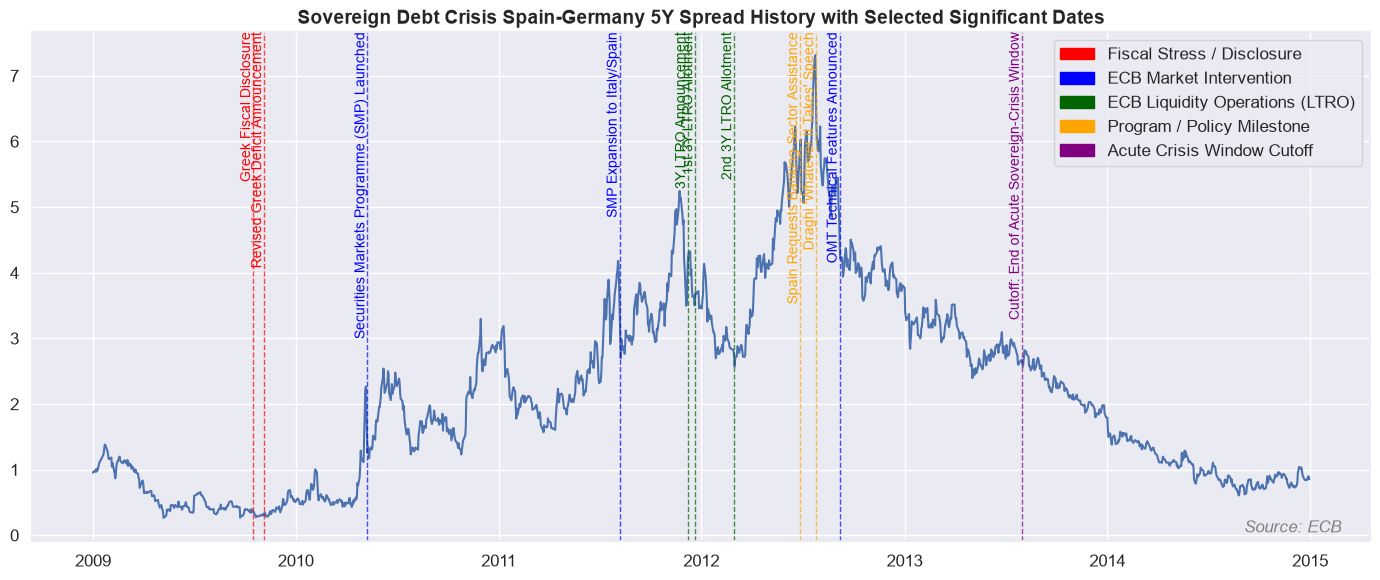

In [97]:
## Overlaying Key Sovereign Crisis Dates on the Spain-Germany 5Y Spread History

#==================
df_filtered = es_de_spread_5y_df.copy()
df_filtered = df_filtered['2009':'2014'].copy()  # Filter data / Zoom
column_label = 'es_de_5y_spread'
year = '5Y'
source = 'ECB'
#==================

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_filtered.index, df_filtered[column_label])
ax.set_title(f'Sovereign Debt Crisis Spain-Germany {year} Spread History with Selected Significant Dates', fontsize=14, fontweight='bold')
annotate_events(ax, df_filtered[column_label], sov_events, position='top')
ax.legend(handles=sov_event_legend, loc='upper right')
fig.text(0.965, 0.09, f'Source: {source}', ha='right', va='bottom', fontsize=12, style='italic', color='gray')
plt.tight_layout()
plt.show()

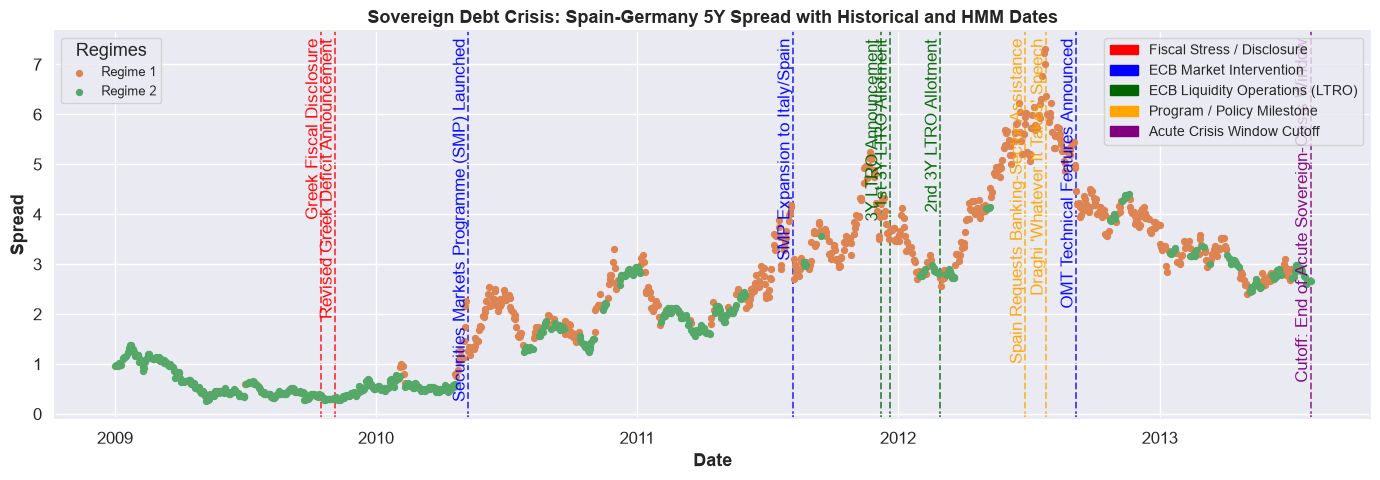

In [98]:
## Overlaying major Sovereign Debt Crisis events on the HMM classified spread level 

e_date=pd.to_datetime('2013-07-31')
looking_back_date = pd.to_datetime('2009-01-01')
ending_date = str(e_date.strftime('%Y-%m-%d'))
zoom_df = new_df.loc[(new_df.index >= looking_back_date) & (new_df.index <= ending_date)]


hmm_transition_dates = []  # replace with your actual list if you have it

if not isinstance(zoom_df.index, pd.DatetimeIndex):
    zoom_df = zoom_df.copy()
    zoom_df.index = pd.to_datetime(zoom_df.index)

fig, ax = plt.subplots(figsize=(14, 5))

# regime scatter points
for regime in sorted(zoom_df['HMM_Regime_Reordered'].dropna().unique()):
    regime_df = zoom_df[zoom_df['HMM_Regime_Reordered'] == regime]
    ax.scatter(
        regime_df.index, regime_df[spread_col],
        s=18, color=f"C{int(regime)}", label=f"Regime {int(regime)}", zorder=2
    )

# y-limits first, then annotate at top
ymin, ymax = ax.get_ylim()
label_y = ymax * 0.98

# event lines + vertical labels
xmin, xmax = zoom_df.index.min(), zoom_df.index.max()
for d, label, c in sov_events:
    dt = pd.to_datetime(d)
    if xmin <= dt <= xmax:
        ax.axvline(dt, color=c, linestyle='--', lw=1.3, alpha=0.75, zorder=0)
        ax.text(
            dt, label_y, label,
            rotation=90, va='top', ha='right',
            color=c, fontsize=12, alpha=0.95, clip_on=True
        )

ax.set_xlabel("Date")
ax.set_ylabel("Spread")
ax.set_title("Sovereign Debt Crisis: Spain-Germany 5Y Spread with Historical and HMM Dates")

# legend: event categories + HMM transition style
event_handles = sov_event_legend
legend_events = ax.legend(handles=event_handles, loc='upper right', frameon=True, fontsize=10)
ax.add_artist(legend_events)

# optional separate regime legend
regime_handles, regime_labels = ax.get_legend_handles_labels()
if regime_handles:
    ax.legend(regime_handles, regime_labels, loc='upper left', frameon=True, fontsize=9, title="Regimes")

plt.tight_layout()
plt.show()

#### HMM and Model Fit Conclusion

* **Usefulness of the HMM:** The two-state Markov-switching AR(1) model provides a useful statistical classification of the Spain-Germany 5-year spread into a higher-spread stress regime and a lower-spread calm regime. The regime split is statistically intuitive, since the stress regime is associated with higher average spreads and greater volatility.

* **Interpretation limits:** The HMM should be interpreted as a complementary regime-dating tool rather than as standalone proof of critical transitions. Although the model identifies persistent calm and stress states, the estimated AR(1) coefficients are almost identical across regimes, meaning it does not directly validate the critical-slowing-down mechanism of complexity theory through higher stress-regime persistence.

* **Model-fit limitations:** The residual diagnostics show that the baseline AR(1) specification does not fully capture the spread dynamics, since residual autocorrelation and ARCH effects remain. This suggests that richer specifications, such as higher-order Markov-switching autoregressive models or models with explicit conditional heteroskedasticity, could improve the statistical fit in future work.